# 1 · Light curves

`LightCurve` is WHISPER's data container: a subclass of `astropy.table.Table` with photometry helpers (SNR cuts, band grouping, magnitude↔flux, phase, plotting). `load_lightcurve` reads a CSV and auto-detects the columns.

This notebook uses the bundled **AT2017GFO** (GW170817 kilonova) g/r/i data.

In [1]:
import numpy as np
from pathlib import Path
import whisper_labia as wp

wp.__version__

'0.0.1.dev0'

## Load

`load_lightcurve` detects time / magnitude (or flux) / error / band / system columns, normalises band names, and resolves each band's effective wavelength + zero point. AT2017GFO sits in NGC 4993 at **z ≈ 0.0098**.

In [2]:
csv = next(p for p in [Path('../tests/data/at2017gfo.csv'),
                       Path('tests/data/at2017gfo.csv')] if p.exists())
lc = wp.load_lightcurve(csv, redshift=0.0098, bands=['g', 'r', 'i'])
print(lc)

       time        band     magnitude      ... lambda_eff zero_point system
------------------ ---- ------------------ ... ---------- ---------- ------
        57982.9814    i              17.48 ...     7545.0     3631.0     AB
         57982.993    r              17.46 ...     6215.0     3631.0     AB
57983.003059500006    i 17.480130787100002 ...     7545.0     3631.0     AB
        57983.0057    g              17.41 ...     4866.0     3631.0     AB
        57983.0106    g              17.41 ...     4866.0     3631.0     AB
        57983.0141    g              17.39 ...     4866.0     3631.0     AB
      57983.018251    i              17.47 ...     7545.0     3631.0     AB
         57983.028    r              17.56 ...     6215.0     3631.0     AB
          57983.05    g              17.32 ...     4866.0     3631.0     AB
          57983.05    i             16.984 ...     7545.0     3631.0     AB
               ...  ...                ... ...        ...        ...    ...
      57990.

/tf/astrodados2/phelipedata2/WHISPER/whisper-labia/whisper_labia/io/bands.py:176: UserWarning: Band 'C' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/tf/astrodados2/phelipedata2/WHISPER/whisper-labia/whisper_labia/io/bands.py:176: UserWarning: Could not resolve band 'C' via SVO (No documented SVO filter ID for band 'C' and no wavelength hint to search with. Pass register_manual_band(...) or a lambda_eff hint.). Effective wavelength / zero point are unknown; supply them with whisper_labia.io.svo.register_manual_band('C', lambda_eff, zero_point).
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/tf/astrodados2/phelipedata2/WHISPER/whisper-labia/whisper_labia/io/bands.py:176: UserWarning: Band 'W' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/tf/astrodados2/phelipedata2/WHISPE

In [3]:
print('points :', lc.n_points)
print('bands  :', lc.bands)
print('columns:', lc.colnames)

points : 213
bands  : ['g', 'i', 'r']
columns: ['time', 'band', 'magnitude', 'magnitude_err', 'lambda_eff', 'zero_point', 'system']


## Quality cuts

Per-point SNR is `lc.snr`. `select_snr` keeps detections above a threshold; slicing and `where` select by band or time window. All return a new `LightCurve`.

In [4]:
print('SNR range:', lc.snr.min().round(1), '->', lc.snr.max().round(1))

good = lc.select_snr(min_snr=5)
print('after SNR>5 :', good.n_points, 'of', lc.n_points)

r_band = lc[lc['band'] == 'r']
print('r-band only :', r_band.n_points, 'points')

SNR range: 2.1 -> 108.6
after SNR>5 : 200 of 213
r-band only : 88 points


## Magnitude ↔ flux

The data is stored in its native mode (here magnitude). `add_flux()` returns a copy with `flux` / `flux_err` columns (AB: `F = 3631 · 10^(-0.4 m)` Jy); `add_mag()` does the reverse.

In [5]:
lcf = lc.add_flux()
print('first 3 mags :', np.round(lc['magnitude'][:3], 2))
print('first 3 flux :', np.round(lcf['flux'][:3] * 1e6, 2), 'µJy')

first 3 mags : [17.48 17.46 17.48]
first 3 flux : [369.85 376.73 369.81] µJy


## Phase (days since merger)

`calc_phase` returns a copy whose `time` column is days since a reference epoch — here the GW170817 merger, MJD 57982.529 — optionally rest-frame-corrected with the redshift.

In [6]:
ph = np.asarray(lc.calc_phase(reference=57982.529).time)
print('phase span:', round(ph.min(), 2), '->', round(ph.max(), 2), 'days')

phase span: 57982.98 -> 57994.97 days


## Plot

`plot_light_curve` has two layouts: `report` (apparent magnitude + flux density, stacked) and `grid` (one panel per band). Detections are circles; low-SNR and upper limits get distinct markers.

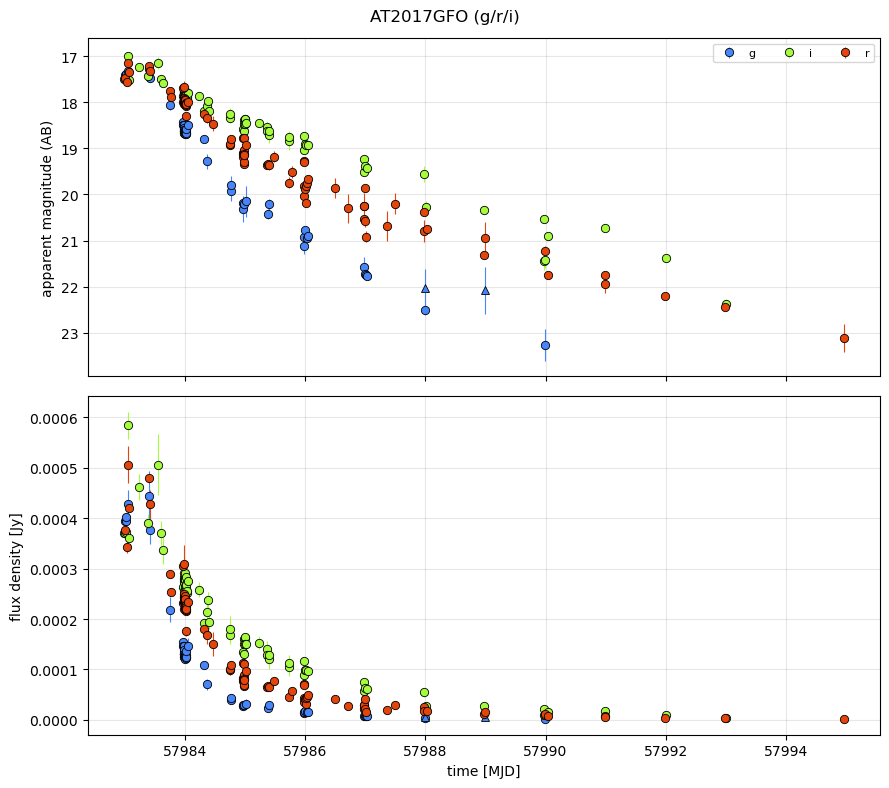

In [7]:
fig = wp.plot_light_curve(lc, layout='report', title='AT2017GFO (g/r/i)')

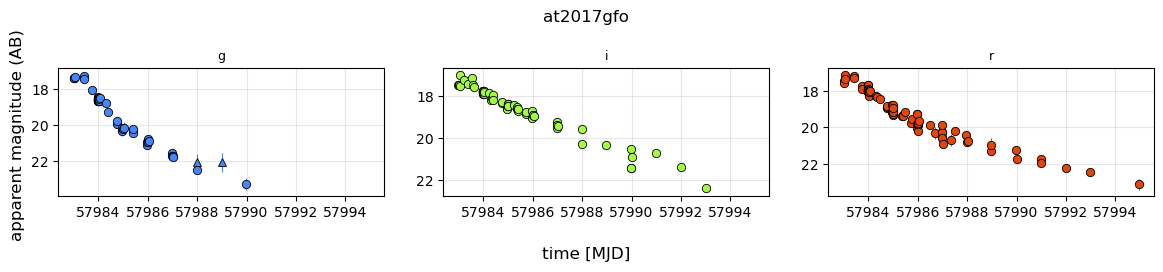

In [8]:
fig = wp.plot_light_curve(lc, layout='grid', quantity='apparent_mag')

**Next:** [2 · Models](02_models.ipynb) — the forward models you fit to this data.